In [33]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datetime import timedelta

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

from sklearn.metrics import *
from tqdm.auto import tqdm

import pennylane as qml
from torchinfo import summary

# Precision settings
np.set_printoptions(precision=3)
torch.set_printoptions(precision=3)

In [34]:
IMG_SIZE = 224
BATCH_SIZE = 6  
EPOCHS = 10
LR = 0.00005     
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [35]:
CSV_PATH = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/HAM10000_metadata.csv"
IMG_DIR = "/kaggle/input/datasets/farjanakabirsamanta/skin-cancer-dataset/Skin Cancer/Skin Cancer"

In [36]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [37]:
class SkinCancerDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

        self.classes = sorted(self.df['dx'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        self.df['label'] = self.df['dx'].map(self.class_to_idx)

        self.image_paths, self.labels = [], []

        for _, row in self.df.iterrows():
            path = os.path.join(self.img_dir, row['image_id'] + ".jpg")
            if os.path.exists(path):
                self.image_paths.append(path)
                self.labels.append(row['label'])

        print(f"Total images: {len(self.image_paths)}")

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [38]:
full_dataset = SkinCancerDataset(CSV_PATH, IMG_DIR, transform)

CLASSES = full_dataset.classes
num_classes = len(CLASSES)

train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

Total images: 10015


In [39]:
import pennylane as qml
import torch
import torch.nn as nn

n_qubits = 4
n_layers = 2

dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    # 🔹 DATA ENCODING (Angle Encoding)
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # 🔹 VARIATIONAL LAYERS
    for l in range(n_layers):

        # Rotation layer
        for i in range(n_qubits):
            qml.RX(weights[l, i], wires=i)
            qml.RZ(weights[l, i], wires=i)

        # 🔹 ENTANGLEMENT (chain + ring)
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i+1])
        qml.CNOT(wires=[n_qubits-1, 0])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]


class QuantumLayer(nn.Module):
    def __init__(self, n_qubits=4):
        super().__init__()
        self.n_qubits = n_qubits

        self.weights = nn.Parameter(
            0.01 * torch.randn(n_layers, n_qubits)
        )

    def forward(self, x):
        outputs = []

        for i in range(x.shape[0]):
            q_in = x[i]

            out = quantum_circuit(q_in, self.weights)

            # 🔥 FIX: enforce float32
            out = torch.stack(out).to(torch.float32)

            outputs.append(out)

        return torch.stack(outputs)

In [40]:
class HybridMobileNet(nn.Module):
    def __init__(self, num_classes, n_qubits=4):
        super().__init__()

        base = models.mobilenet_v2(weights="DEFAULT")
        self.features = base.features

        # Freeze 50%
        freeze_layers = len(self.features)//2
        for i in range(freeze_layers):
            for p in self.features[i].parameters():
                p.requires_grad = False

        # ======================
        # ⚛️ Quantum branch
        # ======================
        self.q_branch = nn.Sequential(
            nn.Conv2d(160, 40, 1),
            nn.BatchNorm2d(40),
            nn.ReLU(),

            nn.Conv2d(40, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )

        # 🔥 CHANGE: output → 4 qubits
        self.q_fc = nn.Linear(8, n_qubits)
        self.quantum = QuantumLayer(n_qubits)

        # ======================
        # 🧠 Classical branch
        # ======================
        self.extra = nn.Sequential(
            nn.Conv2d(1280,128,1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # 🔥 CHANGE: 64 → 96 filters
            nn.Conv2d(128,96,3,padding=1),
            nn.BatchNorm2d(96),
            nn.ReLU()
        )

        # 🔥 CHANGE: input size updated (96 + n_qubits)
        self.final_fc = nn.Linear(96 + n_qubits, num_classes)

    def forward(self,x):
        # Shared backbone (up to layer 17)
        x = self.features[:17](x)

        # ======================
        # ⚛️ Quantum branch
        # ======================
        q = self.q_branch(x)             # (B, 8, 1, 1)
        q = torch.flatten(q,1)           # (B, 8)
        q = torch.tanh(self.q_fc(q))     # (B, 4)
        q = self.quantum(q)              # (B, 4)

        # ======================
        # 🧠 Classical branch
        # ======================
        c = self.features[17:](x)        # (B, 1280, 7, 7)
        c = self.extra(c)                # (B, 96, 7, 7)
        c = nn.functional.adaptive_avg_pool2d(c,(1,1))
        c = torch.flatten(c,1)           # (B, 96)

        # ======================
        # 🔗 Fusion
        # ======================
        out = torch.cat([c,q],dim=1)     # (B, 100)
        return self.final_fc(out)        # (B, num_classes)

In [41]:
model = HybridMobileNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [42]:
def custom_metrics(y_pred, y_true, loss):
    y_pred = torch.argmax(y_pred,1)

    y_true = y_true.cpu().numpy()
    y_pred = y_pred.cpu().numpy()

    return {
        "loss": round(loss,3),
        "accuracy": round(accuracy_score(y_true,y_pred),3)
    }

In [43]:
train_hist = {"loss":[],"accuracy":[]}
val_hist = {"loss":[],"accuracy":[]}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss=0
    preds, labels = [],[]

    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds.append(out)
        labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    train_metrics = custom_metrics(preds,labels,train_loss/len(train_loader))
    train_hist["loss"].append(train_metrics["loss"])
    train_hist["accuracy"].append(train_metrics["accuracy"])

    print("Train:", {k:f"{v:.3f}" for k,v in train_metrics.items()})

    # VALIDATION
    model.eval()
    val_loss=0
    preds, labels = [],[]

    with torch.no_grad():
        for x,y in val_loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out,y)

            val_loss += loss.item()
            preds.append(out)
            labels.append(y)

    preds = torch.cat(preds)
    labels = torch.cat(labels)

    val_metrics = custom_metrics(preds,labels,val_loss/len(val_loader))
    val_hist["loss"].append(val_metrics["loss"])
    val_hist["accuracy"].append(val_metrics["accuracy"])

    print("Val:", {k:f"{v:.3f}" for k,v in val_metrics.items()})


Epoch 1/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '1.114', 'accuracy': '0.659'}
Val: {'loss': '0.656', 'accuracy': '0.778'}

Epoch 2/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.749', 'accuracy': '0.750'}
Val: {'loss': '0.569', 'accuracy': '0.810'}

Epoch 3/10


...

Train: {'loss': '0.298', 'accuracy': '0.913'}
Val: {'loss': '0.485', 'accuracy': '0.840'}

Epoch 9/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.274', 'accuracy': '0.914'}
Val: {'loss': '0.499', 'accuracy': '0.838'}

Epoch 10/10


  0%|          | 0/1169 [00:00<?, ?it/s]

Train: {'loss': '0.233', 'accuracy': '0.932'}
Val: {'loss': '0.551', 'accuracy': '0.842'}


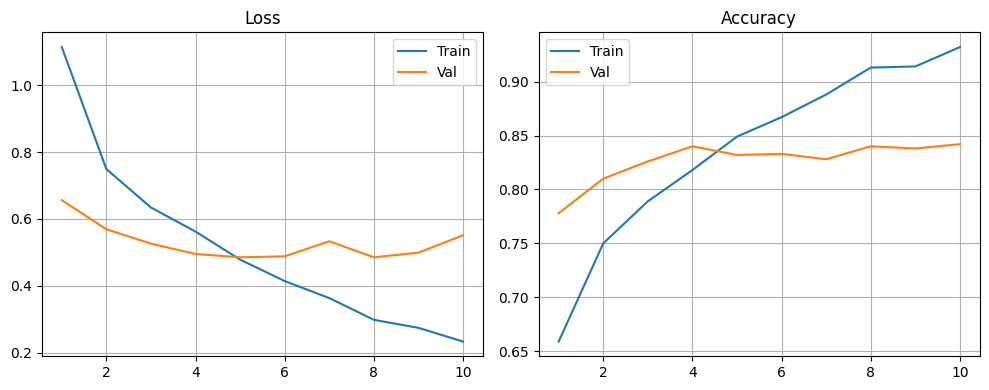

In [44]:
epochs = range(1,len(train_hist["loss"])+1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs,train_hist["loss"],label="Train")
plt.plot(epochs,val_hist["loss"],label="Val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(epochs,train_hist["accuracy"],label="Train")
plt.plot(epochs,val_hist["accuracy"],label="Val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [45]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)

        all_preds.append(out)
        all_labels.append(y)

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

pred_classes = torch.argmax(all_preds, dim=1)

# Classification Report (3 decimal precision)
report = classification_report(
    all_labels.cpu(),
    pred_classes.cpu(),
    target_names=CLASSES,
    digits=3
)

print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       akiec      0.607     0.607     0.607        56
         bcc      0.775     0.696     0.733        79
         bkl      0.721     0.671     0.695       158
          df      0.857     0.600     0.706        20
         mel      0.663     0.350     0.458       163
          nv      0.870     0.959     0.913      1008
        vasc      0.833     0.789     0.811        19

    accuracy                          0.829      1503
   macro avg      0.761     0.668     0.703      1503
weighted avg      0.817     0.829     0.816      1503



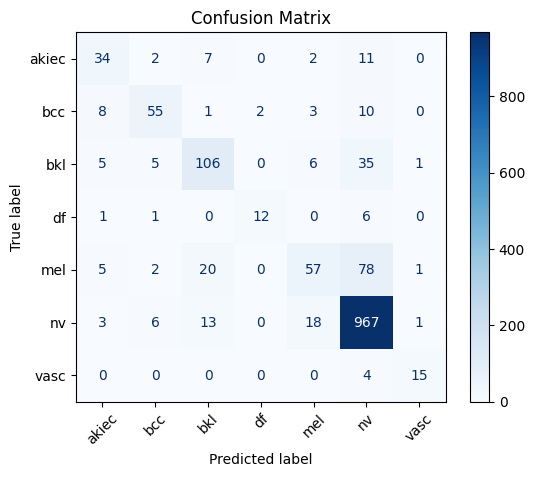

In [46]:
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
disp.plot(cmap="Blues", xticks_rotation=45)

plt.title("Confusion Matrix")
plt.show()

In [47]:
#per class accuracy
cm = confusion_matrix(all_labels.cpu(), pred_classes.cpu())

class_acc = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:\n")
for i, acc in enumerate(class_acc):
    print(f"{CLASSES[i]:<15} : {acc:.3f}")


Per-Class Accuracy:

akiec           : 0.607
bcc             : 0.696
bkl             : 0.671
df              : 0.600
mel             : 0.350
nv              : 0.959
vasc            : 0.789


In [48]:
from graphviz import Digraph

dot = Digraph(format='svg')
dot.attr(rankdir='LR')

# Input
dot.node('Input', 'Input\n[3×224×224]')

# Backbone
dot.node('B1', 'MobileNetV2\n(First 50% Frozen)\n→ [160×7×7]')
dot.edge('Input', 'B1')

# Split
dot.node('Split', 'Split\n[160×7×7]')
dot.edge('B1', 'Split')

# Classical branch
dot.node('C1', 'Remaining MobileNetV2\n→ [1280×7×7]')
dot.node('C2', '1×1 Conv + BN\n→ [128×7×7]')
dot.node('C3', '3×3 Conv + BN\n→ [64×7×7]')
dot.node('C4', 'GAP → Flatten\n→ [64]')

dot.edge('Split', 'C1')
dot.edge('C1', 'C2')
dot.edge('C2', 'C3')
dot.edge('C3', 'C4')

# Quantum branch
dot.node('Q1', '1×1 Conv + BN\n→ [40×7×7]')
dot.node('Q2', '3×3 Conv + BN\n→ [8×7×7]')
dot.node('Q3', 'Pool → Flatten\n→ [8]')
dot.node('Q4', 'Linear → [8]')
dot.node('Q5', 'Quantum Layer\n(8 qubits)')

dot.edge('Split', 'Q1')
dot.edge('Q1', 'Q2')
dot.edge('Q2', 'Q3')
dot.edge('Q3', 'Q4')
dot.edge('Q4', 'Q5')

# Fusion
dot.node('F', 'Concat [64+8=72]')
dot.node('Out', 'Final FC\n→ Classes')

dot.edge('C4', 'F')
dot.edge('Q5', 'F')
dot.edge('F', 'Out')

dot.render('final_architecture', cleanup=True)

print("✅ SVG saved as final_architecture.svg")

✅ SVG saved as final_architecture.svg


In [49]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("\n" + "="*40)
print(f"{'Total Parameters:':<25} {total_params:,}")
print(f"{'Trainable Parameters:':<25} {trainable_params:,}")
print(f"{'Frozen Parameters:':<25} {frozen_params:,}")
print("="*40)


Total Parameters:         2,509,151
Trainable Parameters:     2,378,335
Frozen Parameters:        130,816
